In [ ]:
# Vamos a generar un CLV
# Nos vamos a basar en el código de rfm-segmentation-and-clv-modeling de Raphael (Kaggle)

In [146]:
# Cargamos las librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
from sklearn.cluster import KMeans
#from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler

# import datetime
# from datetime import timedelta
# from datetime import date

# import squarify

# from lifetimes.plotting import *
# from lifetimes.utils import *
# from lifetimes import BetaGeoFitter
# from lifetimes import GammaGammaFitter

# from scipy.stats import gamma, beta

#from sklearn_extra.cluster import KMedoids
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'sklearn_extra'

In [28]:
# Cargamos los datos

df = pd.read_csv('marketing_campaign.csv',header=0,sep=';')

pd.set_option('display.max_columns', None) # para ver todas las columnas


df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [24]:
# Total de registros (compras, interacciones, etc.)
total_clientes = df['ID'].count()

# Número de clientes únicos
clientes_unicos = df['ID'].nunique()

print(f"Total de registros de clientes: {total_clientes}")
print(f"Número de clientes distintos: {clientes_unicos}")

Total de registros de clientes: 2240
Número de clientes distintos: 2240


In [26]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [46]:
#we throw the following question. do we need customers with no operations/recency, etc?
#they are not really interesting, so we better clean them off

df = df[df['Transactions'] > 1] #We keep customers with repeated purchases, implying number of transactions must be at least 2
df = df[df['Spending'] > 0]

In [110]:
# let´s gather the data into something more concise. We need # of transactions and money spent

#df['Spending']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']
df['Spending']=df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['Transactions']=df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)
df.head()



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Spending,Transactions
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,1617,22
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,27,4
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,776,20
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,53,6
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,422,14


In [ ]:
# VAMOS A GENERAR UN RFM


In [236]:
#nos vamos a quedar entonces con la recencia, frencuecia, €

RFM=df[['ID','Spending','Transactions','Recency']]
RFM.head()

,ID,Spending,Transactions,Recency
0,5524,1617,22,58
1,2174,27,4,38
2,4141,776,20,26
3,6182,53,6,26
4,5324,422,14,94


In [132]:
RFM.shape

(2228, 4)

In [134]:
RFM.describe().round(0)

,ID,Spending,Transactions,Recency
count,2228.0,2228.0,2228.0,2228.0
mean,5582.0,608.0,13.0,49.0
std,3245.0,602.0,7.0,29.0
min,0.0,8.0,2.0,0.0
25%,2815.0,69.0,6.0,24.0
50%,5447.0,399.0,12.0,49.0
75%,8416.0,1048.0,18.0,74.0
max,11191.0,2525.0,32.0,99.0


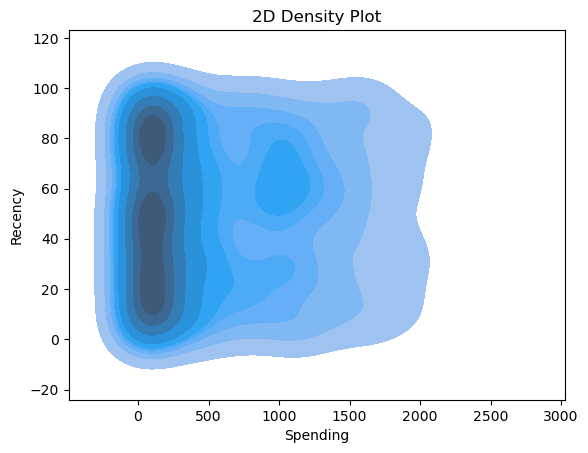

In [268]:
# let´s see how data is distributed

sns.kdeplot(x=df['Spending'], y=df['Recency'], fill=True)
plt.title('2D Density Plot')
plt.show()

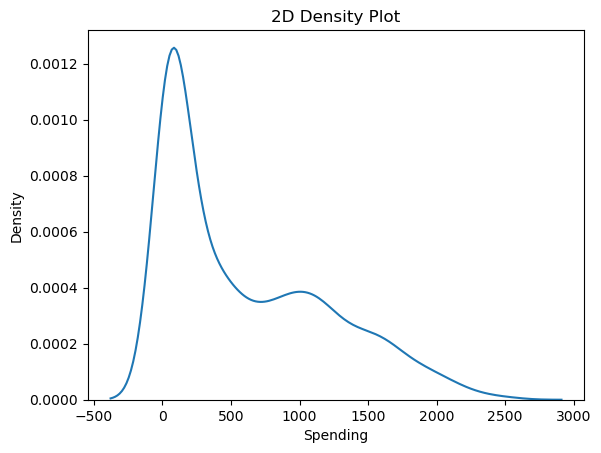

In [230]:
sns.kdeplot(x=df['Spending'])
plt.title('2D Density Plot')
plt.show()

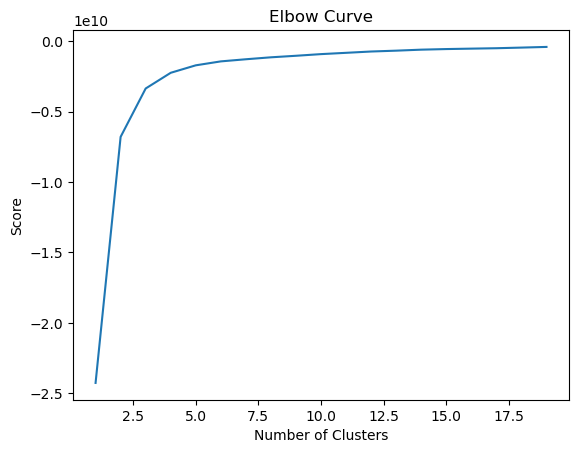

In [136]:
# now let´s see how many groups do we need




# get right number of cluster for K-means so we neeed to loop from 1 to 20 number of cluster and check score.
#Elbow method is used to represnt that. 
Nc = range(1, 20)
kmeans = [KMeans(n_clusters=i) for i in Nc]
score = [kmeans[i].fit(RFM).score(RFM) for i in range(len(kmeans))]
plt.plot(Nc,score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()



In [138]:
RFM.set_index('ID',inplace=True) # quitamos el cliente como variable

In [160]:
# we can take 3-4 clusters. let´s now ufit the data

kmeans =  KMeans(n_clusters=3, random_state=0)
# Kmeans =  KMedoids(n_clusters=3, random_state=0) -> intentaremos mas adelante usar este metodo



kmeans.fit(RFM)
RFM['Cluster'] = kmeans.labels_
RFM.head()



,Spending,Transactions,Recency,Cluster
ID,,,,
5524,1617,22,58,2
2174,27,4,38,0
4141,776,20,26,1
6182,53,6,26,0
5324,422,14,94,0


In [162]:
kmeans.cluster_centers_

array([[ 153.46111111,    7.31190476,   48.7015873 ],
       [ 920.14003295,   19.12191104,   48.8616145 ],
       [1670.02216066,   20.10249307,   50.81440443]])

<Axes: xlabel='Cluster', ylabel='Recency'>

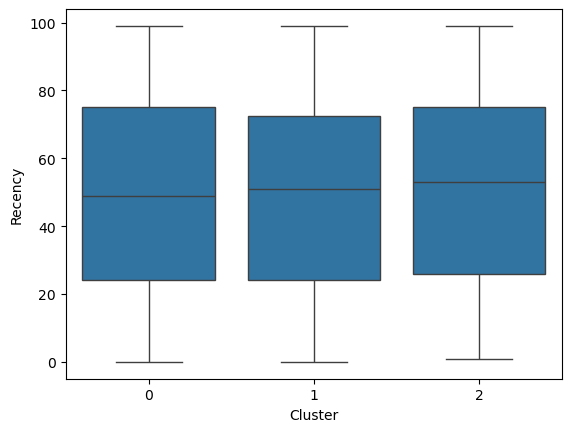

In [164]:
# now let´s understand the segments
sns.boxplot(x=RFM.Cluster, y=RFM.Recency)

<Axes: xlabel='Cluster', ylabel='Spending'>

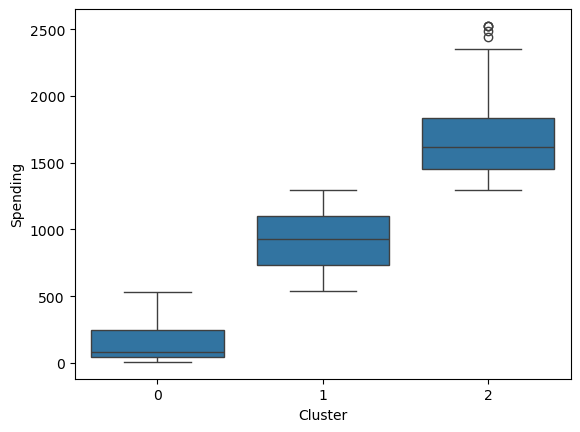

In [166]:
sns.boxplot(x=RFM.Cluster, y=RFM.Spending)

<Axes: xlabel='Cluster', ylabel='Transactions'>

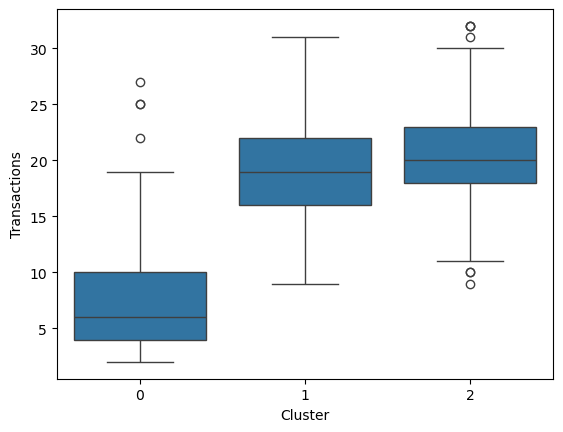

In [168]:
sns.boxplot(x=RFM.Cluster, y=RFM.Transactions)

In [238]:
#Make sure your data is numerical and scaled, especially if the variables are on different scales. Use StandardScaler if needed.
#Unlike KMedoids, KMeans is sensitive to outliers and assumes spherical clusters.

RFM.set_index('ID',inplace=True) # quitamos el cliente como variable
scaler = StandardScaler()
RFM_scaled = scaler.fit_transform(RFM)

kmeans =  KMeans(n_clusters=5, random_state=0)

kmeans.fit(RFM_scaled)
RFM['Cluster'] = kmeans.labels_
RFM.head()

,Spending,Transactions,Recency,Cluster
ID,,,,
5524,1617,22,58,1
2174,27,4,38,2
4141,776,20,26,4
6182,53,6,26,2
5324,422,14,94,0


<Axes: xlabel='Cluster', ylabel='Recency'>

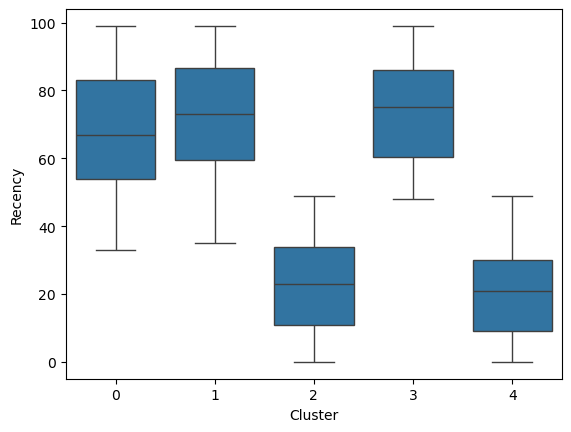

In [240]:
# now let´s understand the segments
sns.boxplot(x=RFM.Cluster, y=RFM.Recency)

<Axes: xlabel='Cluster', ylabel='Spending'>

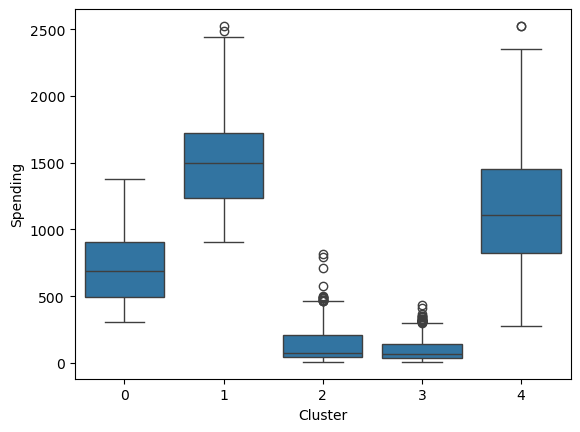

In [242]:
sns.boxplot(x=RFM.Cluster, y=RFM.Spending)

<Axes: xlabel='Cluster', ylabel='Transactions'>

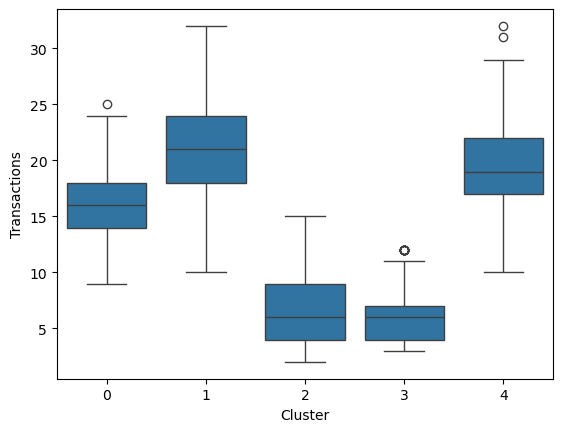

In [244]:
sns.boxplot(x=RFM.Cluster, y=RFM.Transactions)

In [246]:
#let´s rename clusters

segt_map = {
    0: 'silver - at risk',
    1: 'gold - at risk',
    2: 'bronce',
    3: 'broncee - at risk',
    4: 'gold',
 
}

RFM['Cluster_2'] = RFM['Cluster'].map(str)
RFM['Segment'] = RFM['Cluster'].replace(segt_map, regex=True)
RFM.head()

,Spending,Transactions,Recency,Cluster,Cluster_2,Segment
ID,,,,,,
5524,1617,22,58,1,1,gold - at risk
2174,27,4,38,2,2,bronce
4141,776,20,26,4,4,gold
6182,53,6,26,2,2,bronce
5324,422,14,94,0,0,silver - at risk


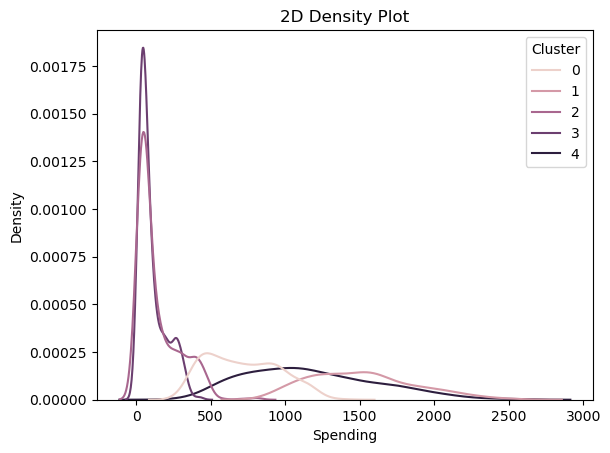

In [270]:
sns.kdeplot(data=RFM, x='Spending', hue='Cluster')  # Pass RFM as the data parameter
plt.title('2D Density Plot')
plt.show()

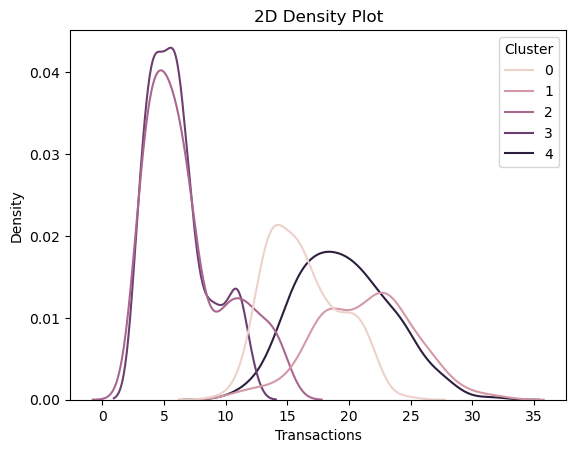

In [272]:
sns.kdeplot(data=RFM, x='Transactions', hue='Cluster')  # Pass RFM as the data parameter
plt.title('2D Density Plot')
plt.show()

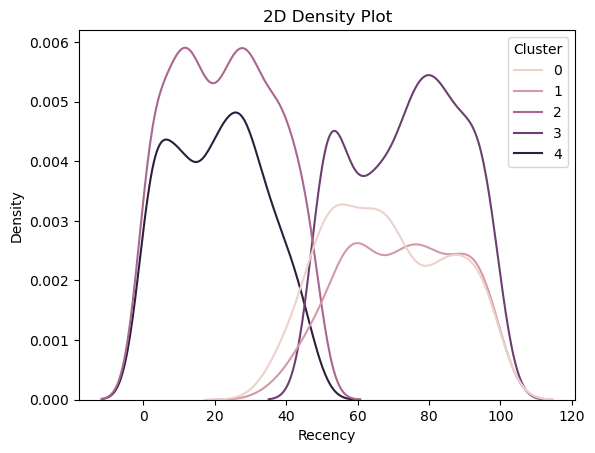

In [274]:
sns.kdeplot(data=RFM, x='Recency', hue='Cluster')  # Pass RFM as the data parameter
plt.title('2D Density Plot')
plt.show()